In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [4]:
df = pd.read_csv("swiggy.csv")

In [5]:
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [7]:
df = df.dropna()

In [9]:
df.isnull().sum()

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64

In [10]:
df.columns

Index(['ID', 'Area', 'City', 'Restaurant', 'Price', 'Avg ratings',
       'Total ratings', 'Food type', 'Address', 'Delivery time'],
      dtype='object')

In [22]:
## Model 

# converting ratings into binary as rate >= 4 as 1 and otherwise 0
df['High_Rating'] = (df["Avg ratings"] >= 4).astype(int)

X = df[['Price', 'Total ratings', 'Delivery time']]
y = df['High_Rating']


# splitting data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25)

# creating model
model = LogisticRegression(max_iter=500)

#training model
model.fit(X_train, y_train)


LogisticRegression(max_iter=500)

In [52]:
# Predict probabilities
probabilities = model.predict_proba(X_test)[:, 1]

# Convert Probabilities into classes (0 or 1)
predicted_class = (probabilities > 0.5).astype(int)

# Print outputs
print("First 10 probabilities:", probabilities[:10])
print("\nFirst 10 predicted classes:", predicted_class[:10])
print("First 10 actual classes:", y_test.values[:10])

First 10 probabilities: [0.31760239 0.66876819 0.34739888 0.63813252 0.47085236 0.45372636
 0.45201096 0.30169166 0.46496795 0.34473615]

First 10 predicted classes: [0 1 0 1 0 0 0 0 0 0]
First 10 actual classes: [1 0 1 1 1 1 0 0 1 0]


In [55]:
model.intercept_

array([-0.09541064])

In [56]:
model.coef_

array([[ 0.0013264 ,  0.00208323, -0.0153692 ]])

In [54]:
y_test.head(10)

7453    1
4970    0
6983    1
3080    1
611     1
4222    1
2754    0
4730    0
3516    1
8616    0
Name: High_Rating, dtype: int32

In [28]:
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time,High_Rating
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59,1
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56,1
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50,1
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57,0
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63,1


In [37]:
## Realword prediction
check = pd.DataFrame([{
    'Price' : 300, 
    'Total ratings' : 800, 
    'Delivery time' : 55
}])

pred = model.predict(check)
print("Will Customer give Higher_Feedback:")
if pred == 1:
    print("Yesss")

else:
    print("Nooo")

Will Customer give Higher_Feedback:
Yesss


In [38]:
## Visualiztion
import matplotlib.pyplot as plt
import seaborn as sns

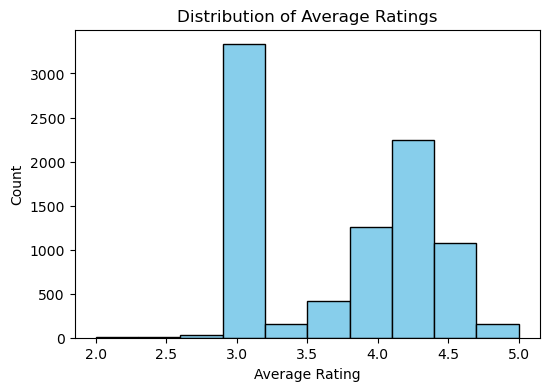

In [50]:
##Histogram for Avg Ratings
plt.figure(figsize=(6,4))
plt.hist(df["Avg ratings"], bins=10,edgecolor="black", color='skyblue')
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Count")
plt.show()

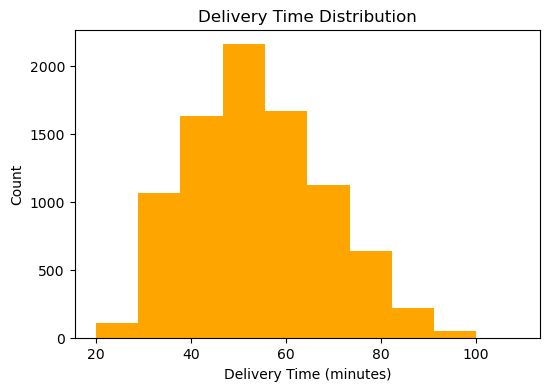

In [44]:
#Histogram for Delivery Time
plt.figure(figsize=(6,4))
plt.hist(df["Delivery time"], bins=10, color='orange')
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Count")
plt.show()

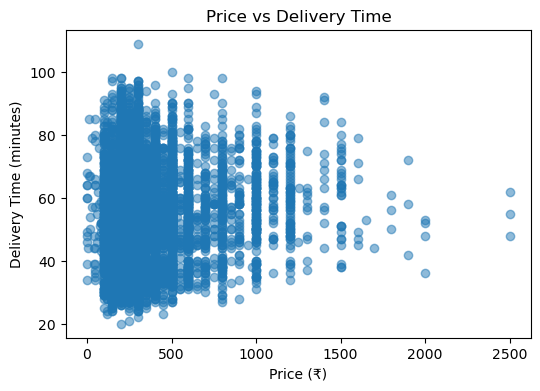

In [45]:
# Scatetr plot: Price vs Delivery time
plt.figure(figsize=(6,4))
plt.scatter(df["Price"], df["Delivery time"], alpha=0.5)
plt.title("Price vs Delivery Time")
plt.xlabel("Price (₹)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

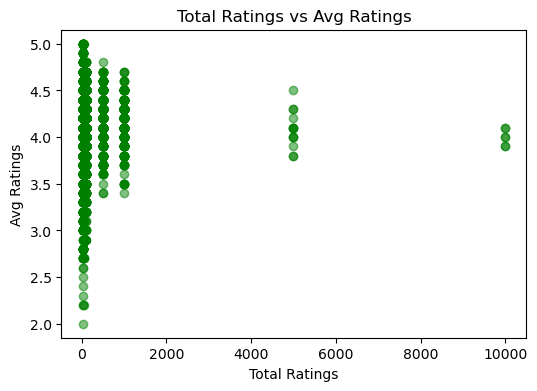

In [47]:
# Scatter plot: Total ratings vs Avg ratings
plt.figure(figsize=(6,4))
plt.scatter(df["Total ratings"], df["Avg ratings"], alpha=0.5, color='green')
plt.title("Total Ratings vs Avg Ratings")
plt.xlabel("Total Ratings")
plt.ylabel("Avg Ratings")
plt.show()

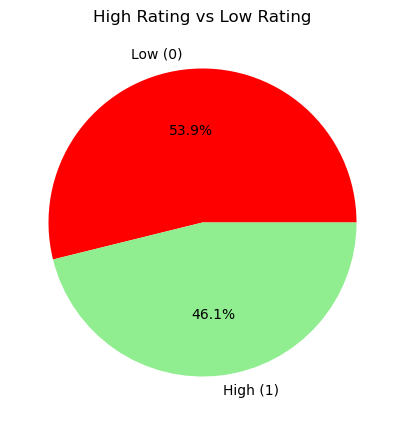

In [48]:
# Pie Chart High rating vs low rating
plt.figure(figsize=(5,5))
df["High_Rating"].value_counts().plot.pie(
    autopct='%1.1f%%', labels=["Low (0)", "High (1)"], colors=['red','lightgreen']
)
plt.title("High Rating vs Low Rating")
plt.ylabel("")
plt.show()


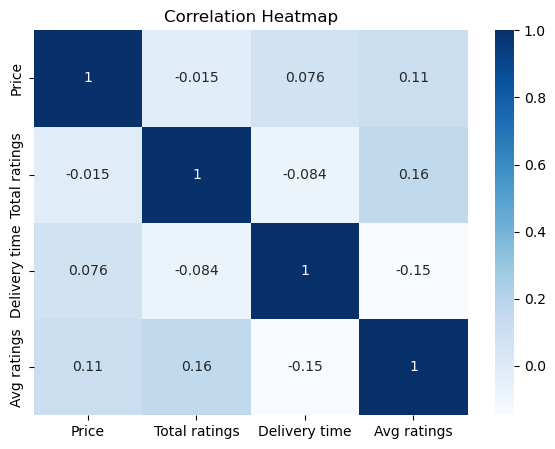

In [49]:
# Correlation Heatmap (all Numeric Features)
plt.figure(figsize=(7,5))
corr = df[["Price","Total ratings","Delivery time","Avg ratings"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

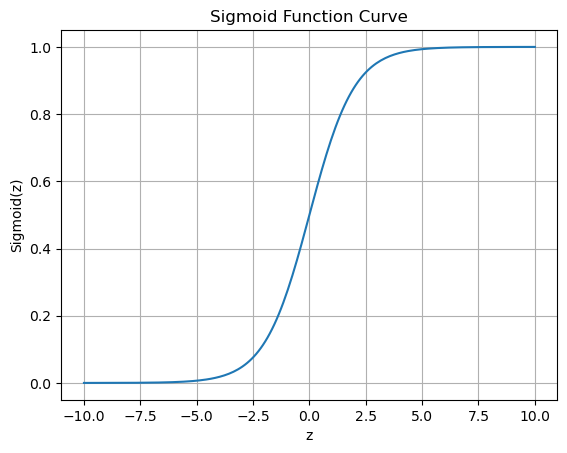

In [57]:
## Sigmoid Curve
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Range of z values
z = np.linspace(-10, 10, 200)

# Compute sigmoid output
p = sigmoid(z)

# Plot
plt.plot(z, p)
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function Curve")
plt.grid(True)
plt.show()


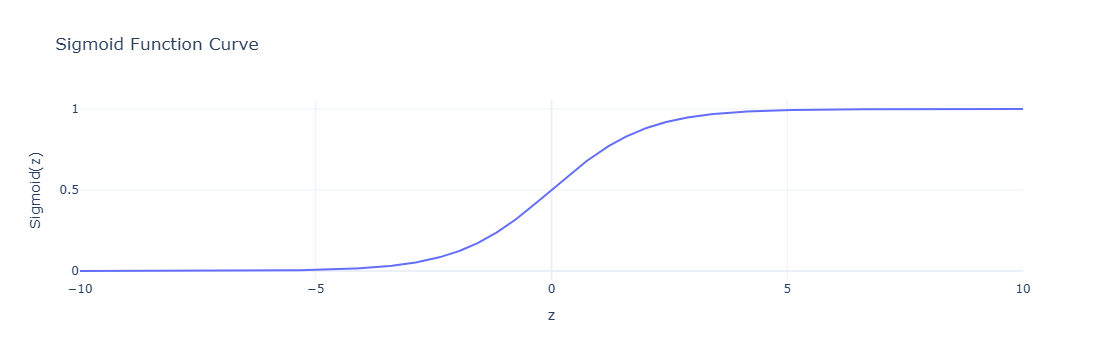

In [61]:
# Plotly 
import numpy as np
import plotly.graph_objects as go

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Range of z values
z = np.linspace(-10, 10, 400)
p = sigmoid(z)

# Create plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=z, 
    y=p,
    mode='lines',
    name='Sigmoid Curve'
))

fig.update_layout(
    title="Sigmoid Function Curve",
    xaxis_title="z",
    yaxis_title="Sigmoid(z)",
    template="plotly_white"
)

fig.show()
